# HFT pipeline

Block-level validation on Uniswap swaps + Binance 1m.


In [41]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from arb.analysis import (
    bootstrap_ci_table,
    compute_descriptive_stats,
    compute_q_regime_grid,
    compute_sensitivity_surface,
    paired_ttest_strategies,
)
from arb.backtest import bootstrap_pnl, compute_sharpe
from arb.config import GAMMA, GAS_REGIMES, GAS_USED, Q_ETH, Q_GRID, SYNTH_REGIMES
from arb.hjb import solve_hjb_1d
from hft.calibrate_hft import build_px_hft, calibrate_hft, fetch_blocks_hft
from hft.backtest_hft import (
    add_model_bids,
    compute_strategy_pnl,
    gas_bid_comparison,
    regime_comparison_hft,
    summary_table,
    walk_forward_hft,
)
from hft.classify_arb import classify_arb_swaps, describe_arb_swaps
from hft.config_hft import END_DATE, MIN_AMOUNT_ETH, MIN_SPREAD_BPS, START_DATE
from hft.fetch_cex import fetch_binance_1m
from hft.fetch_swaps import fetch_pool_swaps
from hft.hft_plots import (
    plot_hft_fig15_hjb_1d,
    plot_hft_gas_alignment,
    plot_hft_stylized_facts_part1,
    plot_hft_stylized_facts_part2,
    save_hft_figure,
)
from hft.state_hft import build_state_hft, describe_state_hft

os.makedirs('../outputs/figures', exist_ok=True)
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## 1. Загрузка данных

In [42]:
Q = Q_ETH
swaps_raw = fetch_pool_swaps(START_DATE, END_DATE, verbose=True)
print(len(swaps_raw))


732530


In [43]:
cex_1m = fetch_binance_1m(START_DATE, END_DATE, verbose=True)
print(len(cex_1m))


172801


In [44]:
blocks = fetch_blocks_hft(START_DATE, END_DATE, n_samples=500, verbose=True)
print(len(blocks))


167


---
## 2. Классификация арб-свапов

In [45]:
arb = classify_arb_swaps(swaps_raw, cex_1m, min_spread_bps=MIN_SPREAD_BPS, min_amount_eth=MIN_AMOUNT_ETH)
print(len(swaps_raw), len(arb))
print(describe_arb_swaps(arb).to_string())


732530 182562
                                     value
n_swaps                             182562
date_range         2025-12-31 → 2026-04-30
mean_spread_bps                      13.35
median_spread_bps                     8.44
mean_amount_eth                       25.9
median_gas_gwei                       0.78
mean_gas_gwei                        10.53
mean_gross_pnl                       92.98
mean_gas_cost                         3.36
mean_net_pnl                         89.61
pct_profitable                        99.1


---
## 3. Сборка панели

In [46]:
from hft.calibrate_hft import build_px_hft

px = build_px_hft(swaps_raw, cex_1m)
print(len(px), px.index[0], px.index[-1])


172703 2025-12-31 21:01:00+00:00 2026-04-30 20:59:00+00:00


In [47]:
desc = compute_descriptive_stats(px.rename(columns={'cex_close': 'cex_close', 'dex_mid': 'dex_mid'}), blocks=blocks)
print(desc.to_string())


                               N       Mean       Std        Min     Median        Max     Skew      Kurt  Freq
Variable                                                                                                       
CEX price S^C (USD)       172703  2370.3595  445.0441  1752.1000  2185.5600  3391.6400   0.9656   -0.5804    1h
DEX mid price S^D (USD)   172703  2369.6320  444.3942  1708.5142  2186.0111  3398.4041   0.9653   -0.5765    1h
Spread |S^C − S^D| (USD)  172703     1.3508    1.5178     0.0000     0.9771   107.8119  14.2216  617.0554    1h
Spread (bps)              172703     5.4808    6.1045     0.0000     4.3612   455.4388  19.9388  972.0713    1h
CEX log-return (hourly)   172703    -0.0002    0.0953    -3.8216     0.0000     4.4522   0.8861   77.5405    1h
DEX log-return (hourly)   172703    -0.0002    0.0898    -3.9459     0.0000     3.8816   0.3066  145.9304    1h
Base fee (gwei)              167     0.1635    0.0295     0.0933     0.1727     0.2182  -1.0153   -0.111

---
## 4. Калибровка параметров

In [48]:
params, px_cal = calibrate_hft(swaps_raw, cex_1m, blocks, Q=Q)
for k in ('sigma_c', 'sigma_d', 'rho', 'kappa', 'beta', 'S0', 'g_lo', 'g_hi'):
    print(k, params.get(k))


sigma_c 0.6398721409191139
sigma_d 0.6397462722301055
rho 0.9967126075832822
kappa 49723.00010138364
beta 4.008184202584476
S0 2264.34
g_lo 0.22265305600000002
g_hi 10.222653056


---
## 5. Стилизованные факты

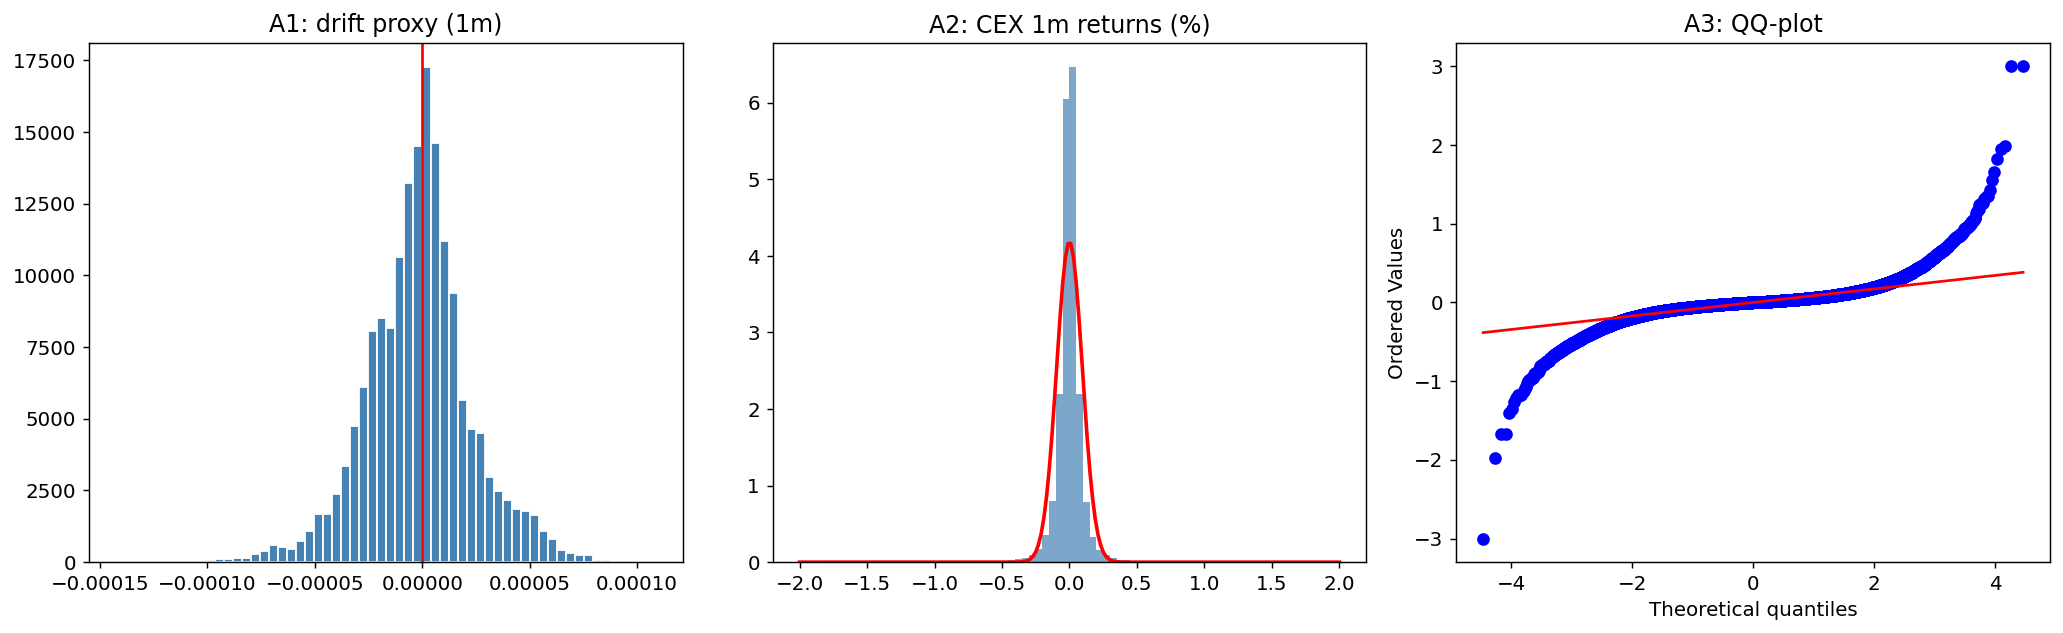

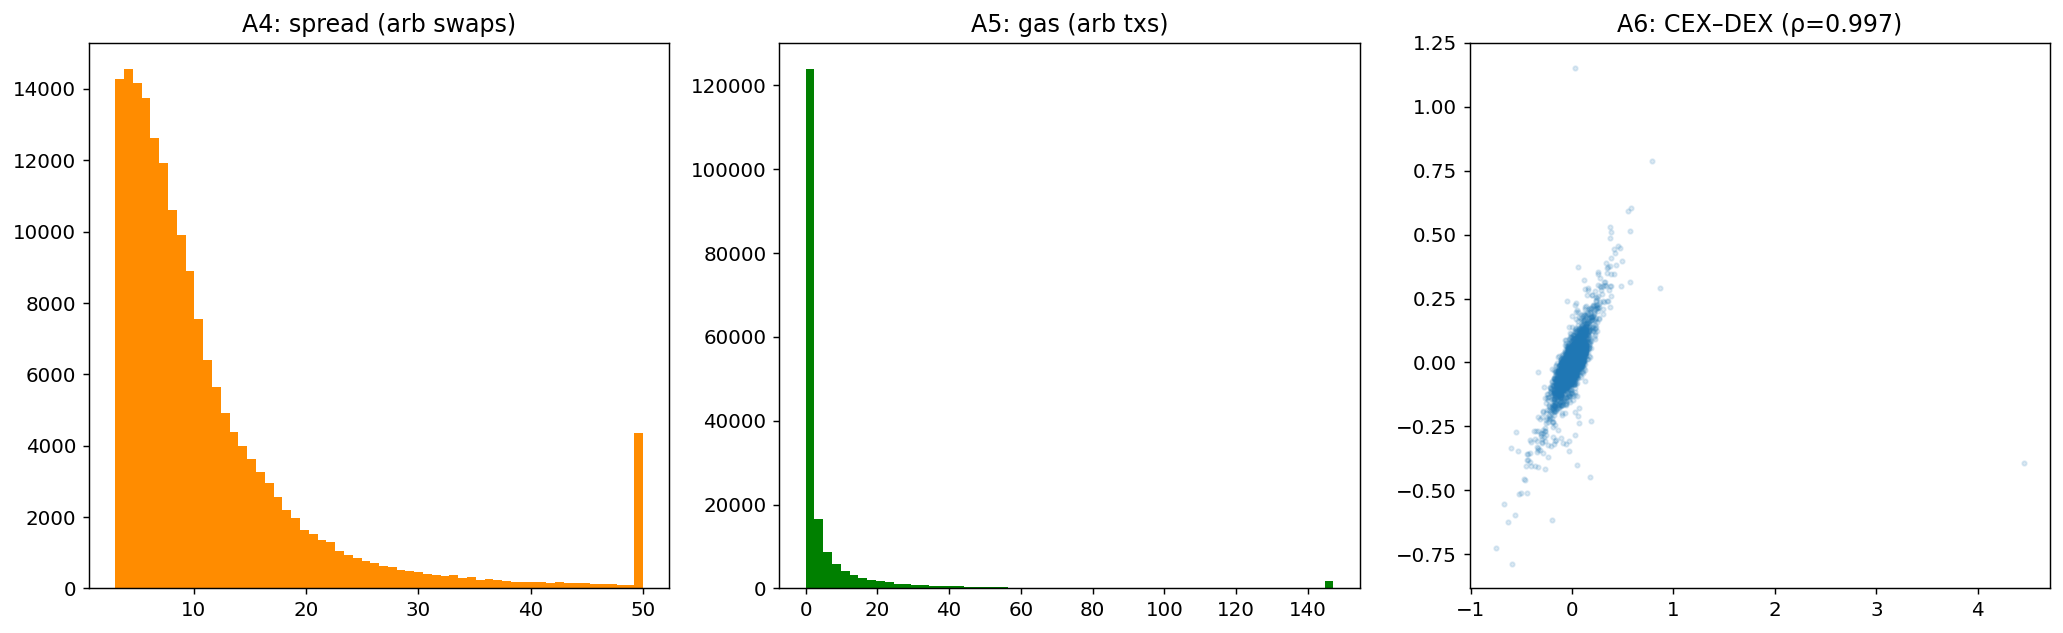

In [49]:
fig = plot_hft_stylized_facts_part1(px, float(params['rho']))
save_hft_figure(fig, 'fig14a_hft_stylized_facts')
plt.show()
fig = plot_hft_stylized_facts_part2(px, arb, float(params['rho']))
save_hft_figure(fig, 'fig14b_hft_stylized_facts')
plt.show()


---
## 6. Решение HJB (1D сетка)

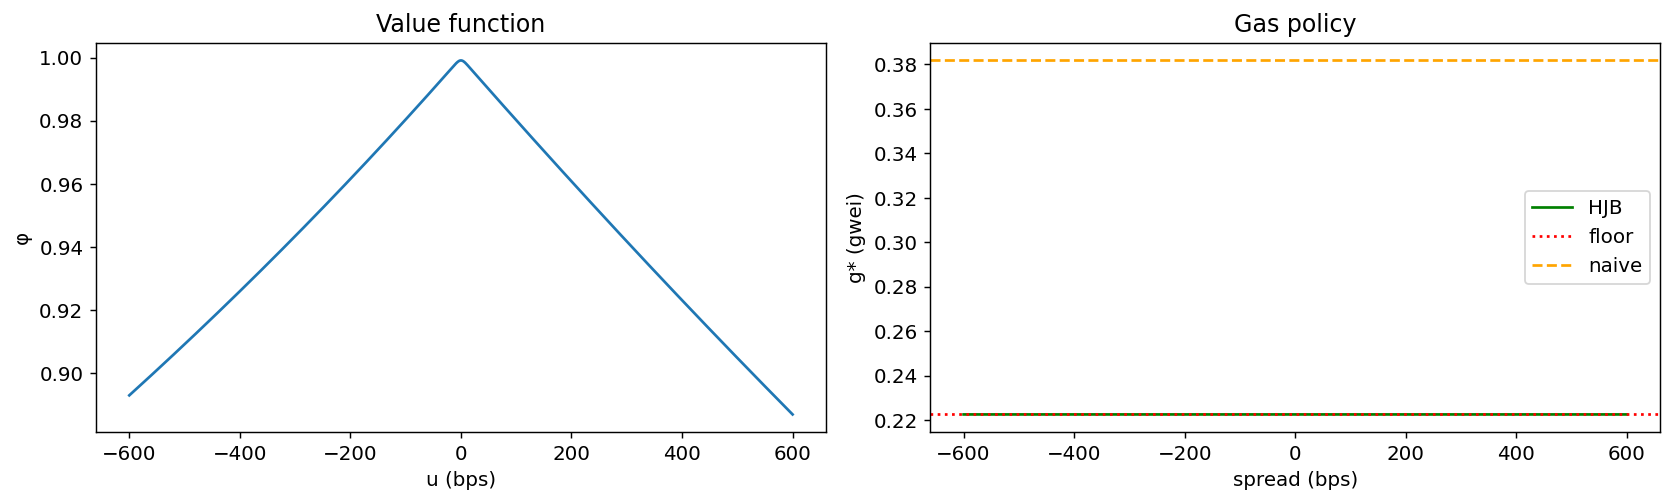

In [50]:
from arb.config import N_T_HJB, N_Z_HJB

u_hjb, phi_hjb, g_star_hjb = solve_hjb_1d(params, gamma=GAMMA, Q=Q)
naive_gwei = float(params.get('propose_gwei', params['g_lo']))
fig = plot_hft_fig15_hjb_1d(
    u_hjb, phi_hjb, g_star_hjb,
    params['g_lo'], naive_gwei,
)
save_hft_figure(fig, 'fig15_hft_hjb_1d')
plt.show()

_hjb_cache = Path('../outputs/figures/hjb_1d_fig15_cache.npz')
np.savez_compressed(
    _hjb_cache,
    u_hjb=u_hjb, phi_hjb=phi_hjb, g_star_hjb=g_star_hjb,
    g_lo=float(params['g_lo']), naive_gwei=naive_gwei,
)


### HJB cache replot


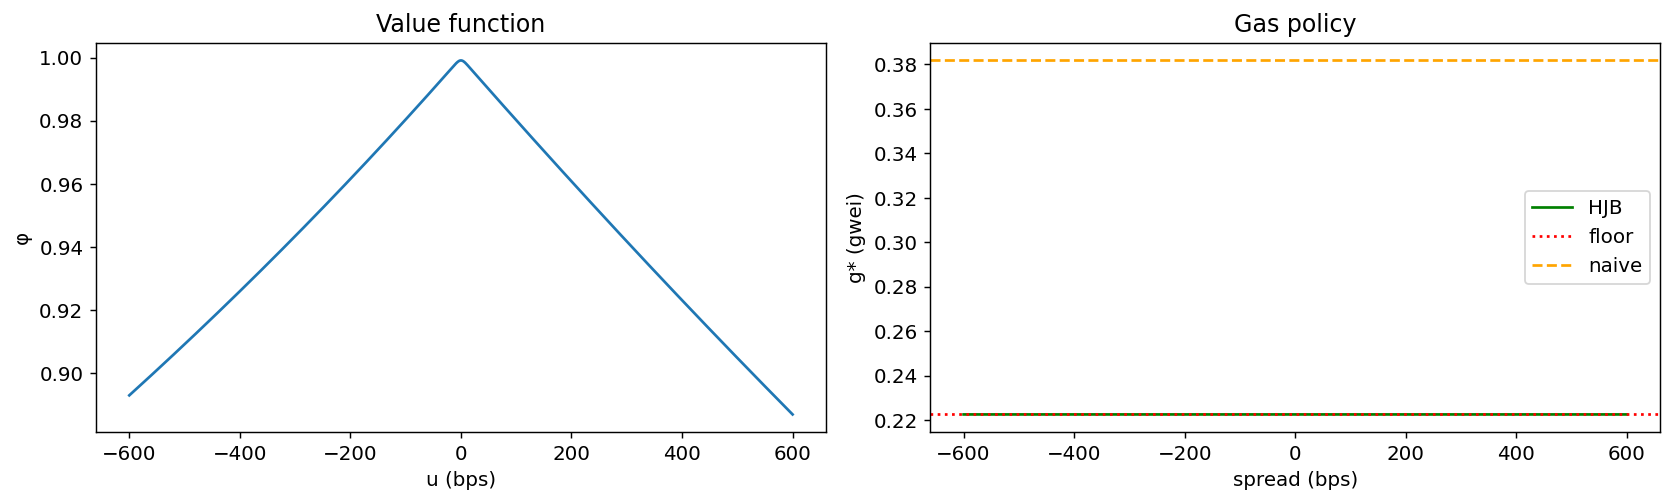

In [51]:
import pickle
from pathlib import Path

cache = Path('../outputs/figures/hjb_1d_fig15_cache.npz')
if not cache.exists():
    raise FileNotFoundError('run HJB cell first')
d = np.load(cache)
_naive = float(d['naive_gwei'])
fig = plot_hft_fig15_hjb_1d(
    d['u_hjb'], d['phi_hjb'], d['g_star_hjb'],
    float(d['g_lo']), _naive,
)
save_hft_figure(fig, 'fig15_hft_hjb_1d')
plt.show()


## 6.1 Сходимость HJB

In [52]:
from arb.config import HJB_CONVERGENCE_CHECK, N_T_HJB_HEAVY, N_Z_HJB_HEAVY
if HJB_CONVERGENCE_CHECK:
    u_ref, _, g_ref = solve_hjb_1d(params, N_z=min(N_Z_HJB_HEAVY, 4000), N_t=N_T_HJB_HEAVY, Q=Q)
    print(len(u_ref), g_ref.min(), g_ref.max())


4000 0.22265305600000002 0.22265305600000002


## 6.2 2D HJB верификация (опционально)

In [53]:
# from arb.config import HJB_2D_ACTIVE, N_X_HJB_XY, N_Y_HJB_XY, N_T_HJB_XY, G_SCAN
# from arb.hjb import solve_hjb_2d_xy

# if HJB_2D_ACTIVE:
#     xg_2d, yg_2d, phi_2d, g_star_2d, meta_2d = solve_hjb_2d_xy(params, Q=Q)
#     mid_ix = N_X_HJB_XY // 2
#     u_2d_slice = xg_2d[mid_ix] - yg_2d
#     phi_2d_slice = phi_2d[:, mid_ix]
#     phi_1d_on_2d = np.interp(u_2d_slice, u_hjb, phi_hjb)
#     err_2d = np.max(np.abs(phi_2d_slice - phi_1d_on_2d))
#     print(err_2d)


---
## 7. Построение opportunity set

In [54]:
state = build_state_hft(arb, px, params, Q=Q, roll_min=60)
print(len(state))
print(describe_state_hft(state).to_string())


182562
                      N       Mean       Std        Min     Median         Max
Variable                                                                      
CEX price (USD)  182562  2251.2162  385.0638  1752.1000  2108.9000   3391.6400
DEX price (USD)  182562  2250.0267  384.6259  1668.7984  2108.4621   3397.8044
|spread| (USD)   182562     2.9843    5.8505     0.5493     1.8597    380.6626
|spread| (bps)   182562    13.3496   27.2560     3.0001     8.4365   1857.0717
size (ETH)       182562    25.8986   52.6075     1.0000     8.7821   4263.1367
gas (gwei)       182562    10.5266  113.3744     0.0201     0.7804  27213.3504
g* CF (gwei)     182562     1.2045    0.3704     0.4254     1.1352      3.5492


---
## 8. Бэктест: HJB vs CF vs Naive

In [55]:
arb_bids = add_model_bids(state, params, u_hjb=u_hjb, g_star_hjb=g_star_hjb, Q=Q)
print(arb_bids[['inc_cf', 'inc_hjb', 'inc_naive']].mean())


inc_cf       0.461619
inc_hjb      0.330408
inc_naive    0.414024
dtype: float64


In [56]:
pnl = compute_strategy_pnl(arb_bids, params, Q=Q)
print(summary_table(pnl).to_string())


          n_trades    total_pnl  mean_pnl  sharpe  win_rate  mean_g_gwei
strategy                                                                
Actual      182562  16306590.95     89.32   0.062     0.989       10.527
CF           84274   6247099.97     74.13   0.049     1.000        0.562
HJB          60320   4925066.17     81.65   0.046     1.000        0.223
Naive        75585   5774617.05     76.40   0.048     1.000        0.382


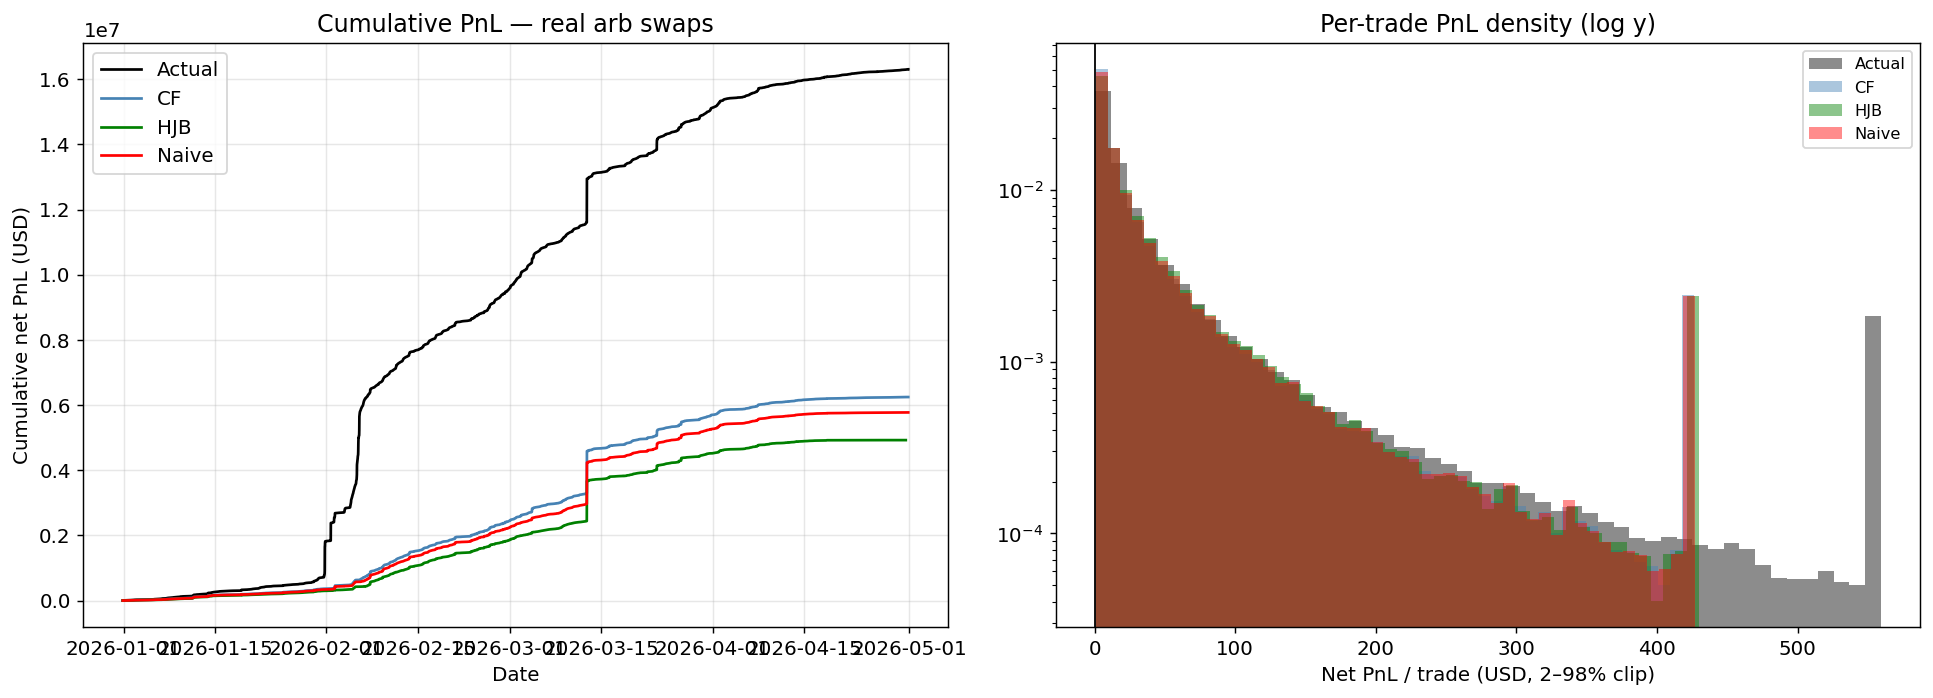

In [57]:
colors = {'Actual': 'black', 'CF': 'steelblue', 'HJB': 'green', 'Naive': 'red'}
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
for name, bt in pnl.items():
    if bt.empty: continue
    cum = bt.set_index('dt')['net_pnl_usd'].sort_index().cumsum()
    ax.plot(cum.index, cum.values, label=name, color=colors.get(name, 'gray'), lw=1.5)
ax.set(xlabel='Date', ylabel='Cumulative net PnL (USD)', title='Cumulative PnL — real arb swaps')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for name, bt in pnl.items():
    if bt.empty: continue
    pv = bt['net_pnl_usd']
    lo, hi = pv.quantile(0.02), pv.quantile(0.98)
    pv = pv.clip(lo, hi)
    ax.hist(pv, bins=50, alpha=0.45, label=name, density=True, color=colors.get(name, 'gray'))
ax.axvline(0, color='black', lw=1)
ax.set_yscale('log')
ax.set(xlabel='Net PnL / trade (USD, 2–98% clip)', title='Per-trade PnL density (log y)')
ax.legend(fontsize=9)

plt.tight_layout()
save_hft_figure(fig, 'fig16_hft_backtest')
plt.savefig('../outputs/hft_pnl_backtest.png', bbox_inches='tight')
plt.show()


## 8.1 Статистическая значимость (paired t-test)

In [58]:
from collections import defaultdict
from scipy.stats import ttest_1samp

by_ts = defaultdict(list)
for _, row in pnl['CF'].iterrows():
    by_ts[row['timestamp']].append(row)
aligned = []
for ts, rows_nv in zip(pnl['Naive']['timestamp'], pnl['Naive']['net_pnl_usd']):
    cf_rows = by_ts.get(ts, [])
    if cf_rows:
        aligned.append(rows_nv - cf_rows[0]['net_pnl_usd'])
if aligned:
    d = np.array(aligned)
    t, p = ttest_1samp(d, 0.0)
    print(len(d), d.mean(), p)


75585 5.6456586890681795 0.19672444012000342


## 8.2 Bootstrap CI

In [59]:
boot_rows = []
for name, bt in pnl.items():
    if bt.empty:
        continue
    ci = bootstrap_pnl(bt)
    if ci:
        boot_rows.append({'strategy': name, **ci})
if boot_rows:
    print(pd.DataFrame(boot_rows).set_index('strategy').to_string())


            mean_lo    mean_hi  sharpe_lo  sharpe_hi
strategy                                            
Actual    83.440906  96.690317   0.051933   0.083275
CF        65.119993  85.662818   0.039598   0.094398
HJB       69.760912  95.970156   0.037676   0.080921
Naive     66.943248  88.917087   0.038496   0.083147


---
## 9. Gas bid: модель vs реальность

In [60]:
print(gas_bid_comparison(arb_bids).to_string())


       mean_actual  mean_model    bias     mae  corr  pct_undercut
model                                                             
CF          10.527       0.562  -9.964  10.327   NaN          53.8
HJB         10.527       0.223 -10.304  10.388   NaN          67.0
Naive       10.527       0.382 -10.145  10.348   NaN          58.6


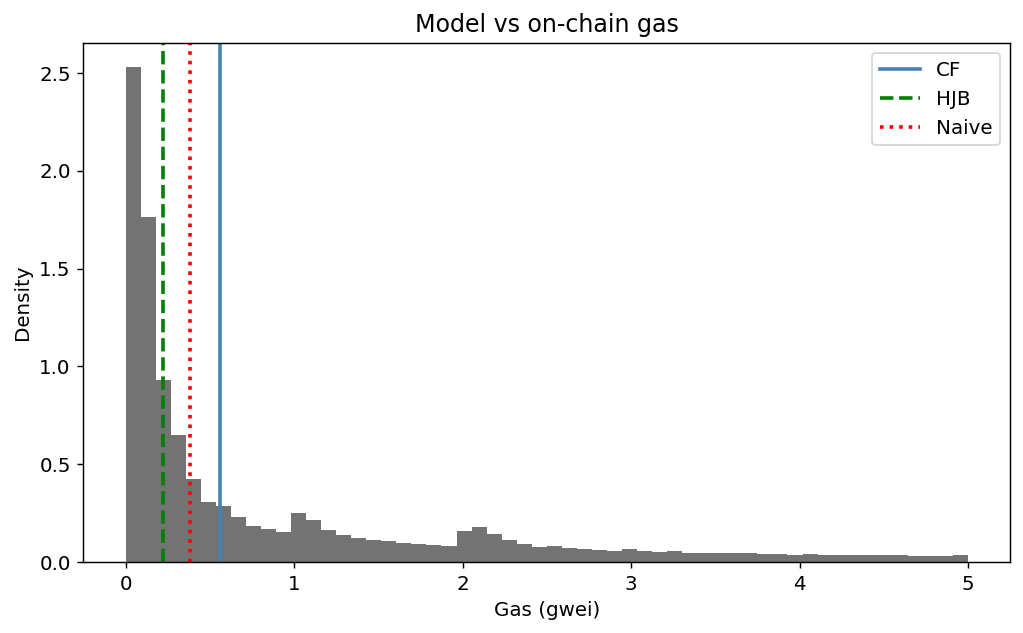

In [61]:
fig = plot_hft_gas_alignment(arb_bids, cap_q=0.97)
save_hft_figure(fig, 'fig17_hft_gas_alignment')
plt.savefig('../outputs/hft_gas_comparison.png', bbox_inches='tight')
plt.show()


---
## 10. Q × Режим газа

In [62]:
gas_regimes = {'calm_current': dict(params)}
for rname, synth in SYNTH_REGIMES.items():
    if rname in gas_regimes:
        continue
    p = dict(params)
    p.update(synth)
    p['g_lo'] = synth['base_fee'] + 0.05
    p['g_hi'] = synth['propose_gwei'] * 3.0
    gas_regimes[rname] = p


---
## 11. Режимный бэктест

In [63]:
regime_df = regime_comparison_hft(state, params, gas_regimes, u_hjb, g_star_hjb, Q=Q)
print(regime_df.round(3).to_string())


               regime strategy  n_trades    total_pnl  sharpe  win_rate  mean_g_gwei  delta_sharpe_vs_naive
0        calm_current   Actual    182562  16306590.95   0.062     0.989       10.527                  0.014
1        calm_current       CF    101867   7900180.30   0.047     1.000        1.174                 -0.001
2        calm_current      HJB     60320   4925066.17   0.046     1.000        0.223                 -0.002
3        calm_current    Naive     75585   5774617.05   0.048     1.000        0.382                  0.000
4        calm_apr2026   Actual    182562  16306590.95   0.062     0.989       10.527                  0.018
5        calm_apr2026       CF    153126   9644416.02   0.046     0.859        8.940                  0.002
6        calm_apr2026      HJB     60320   4925066.17   0.046     1.000        0.223                  0.001
7        calm_apr2026    Naive    129050   8497587.92   0.045     0.978        3.000                  0.000
8    moderate_may2022   Actu

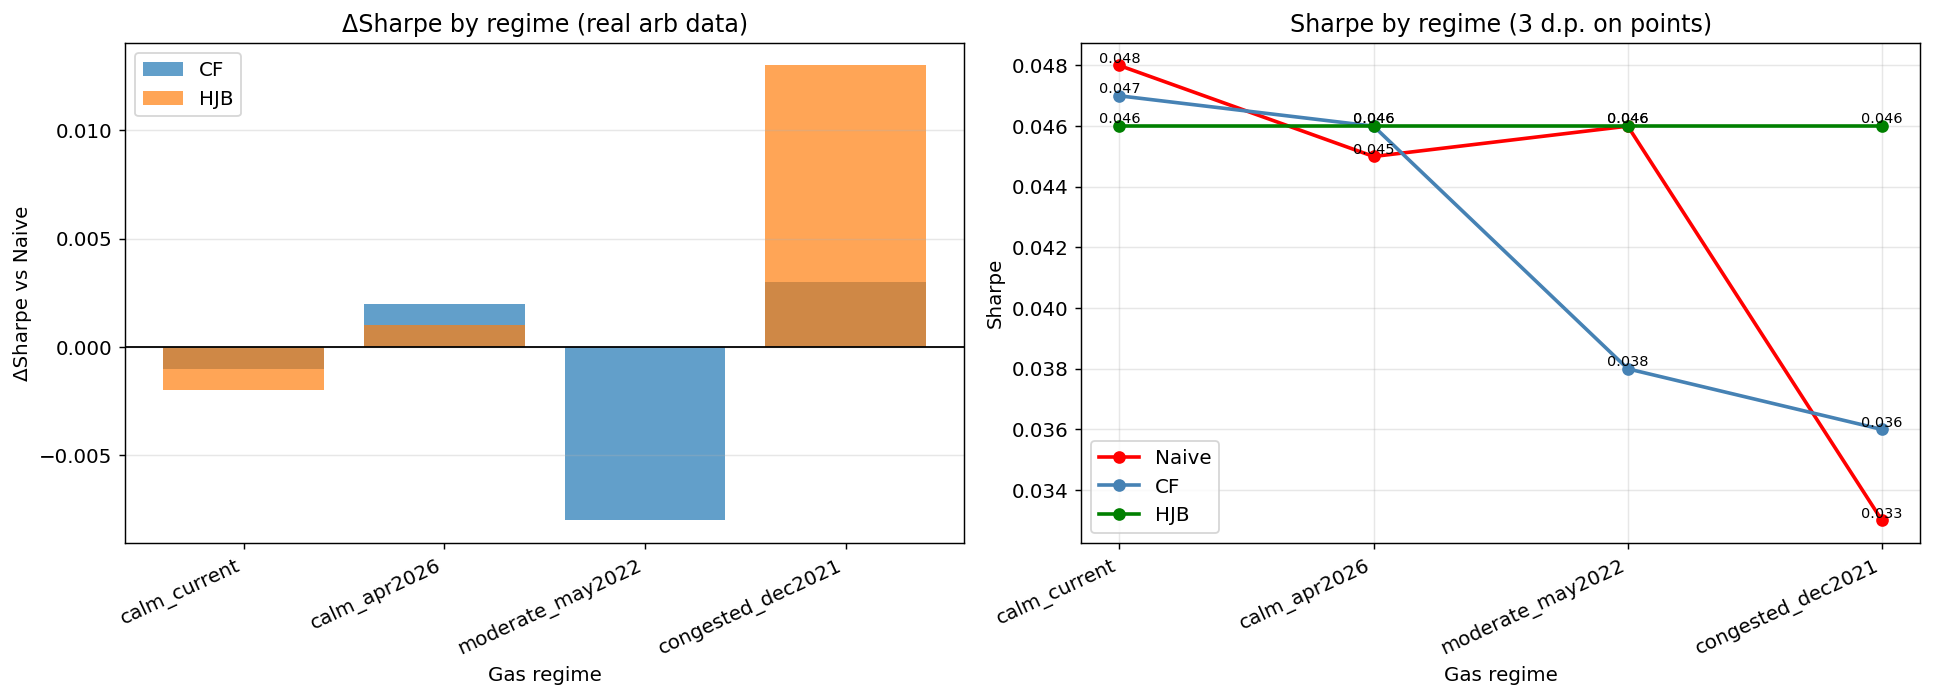

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
for strat in ['CF', 'HJB']:
    sub = regime_df[regime_df['strategy'] == strat]
    if sub.empty: continue
    ax.bar(sub['regime'], sub['delta_sharpe_vs_naive'],
           alpha=0.7, label=strat)
ax.axhline(0, color='black', lw=1)
ax.set(xlabel='Gas regime', ylabel='ΔSharpe vs Naive',
       title='ΔSharpe by regime (real arb data)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

ax = axes[1]
for strat, color in [('Naive', 'red'), ('CF', 'steelblue'), ('HJB', 'green')]:
    sub = regime_df[regime_df['strategy'] == strat]
    if sub.empty: continue
    xs = sub['regime'].values
    ys = sub['sharpe'].values
    ax.plot(xs, ys, 'o-', label=strat, color=color, lw=2)
    for x, y in zip(xs, ys):
        ax.text(x, y, f'{y:.3f}', fontsize=8, ha='center', va='bottom' if y >= 0 else 'top')
ax.set(xlabel='Gas regime', ylabel='Sharpe', title='Sharpe by regime (3 d.p. on points)')
ax.legend(); ax.grid(alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha='right')

plt.tight_layout()
save_hft_figure(fig, 'fig18_hft_regime_counterfactual')
plt.savefig('../outputs/hft_regime_comparison.png', bbox_inches='tight')
plt.show()


---
## 12. Поверхность чувствительности γ × Q

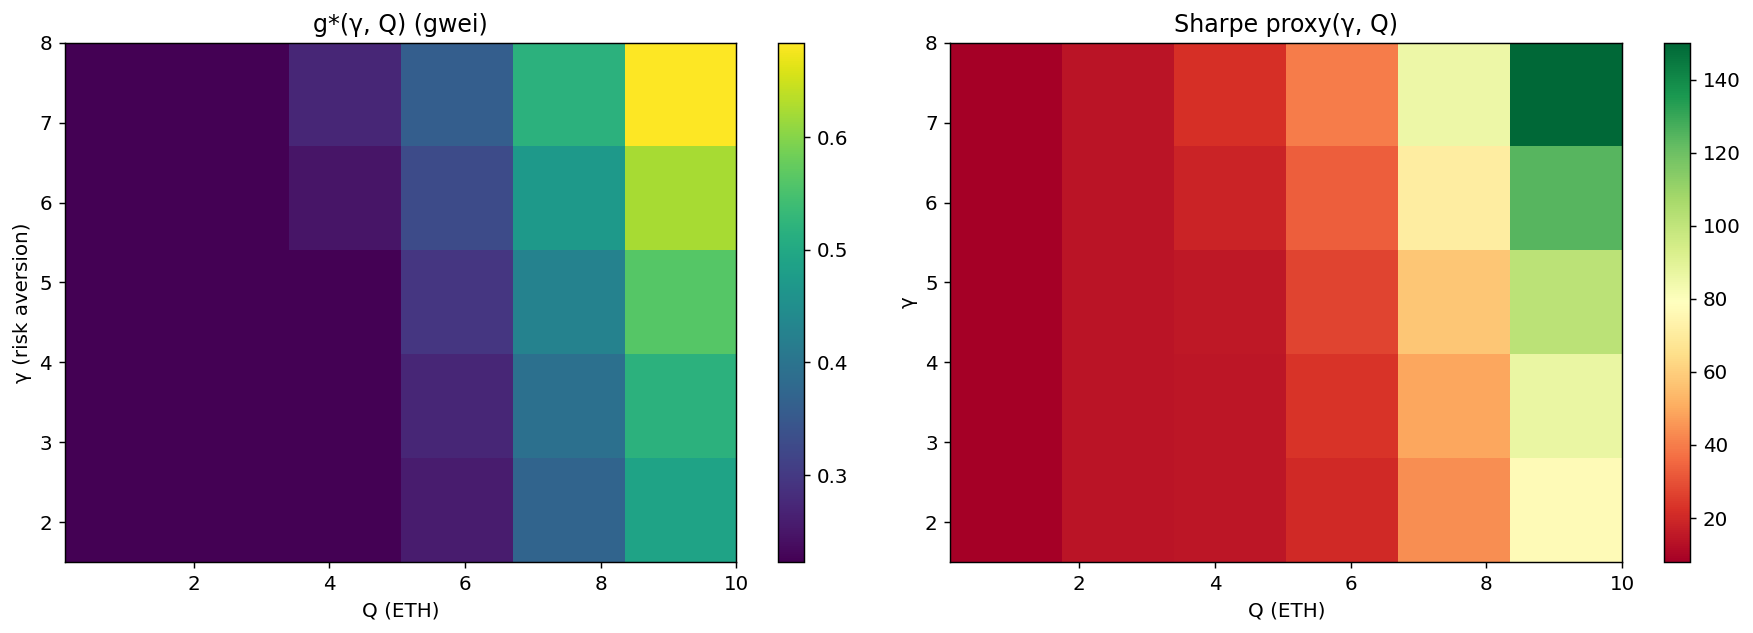

In [65]:
gammas_s = np.array([1.5, 2.0, 3.0, 5.0, 8.0])
Qs_s     = np.array([0.1, 0.5, 1.0, 2.0, 5.0, 10.0])
median_spread_usd = float(arb['spread_usd'].abs().median())

g_surf, g_raw_surf, tau_surf, sh_surf = compute_sensitivity_surface(
    params, gammas_s, Qs_s, median_spread_usd=median_spread_usd, S=params['S0']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(g_surf, aspect='auto', origin='lower', cmap='viridis',
                      extent=[Qs_s[0], Qs_s[-1], gammas_s[0], gammas_s[-1]])
axes[0].set(xlabel='Q (ETH)', ylabel='γ (risk aversion)', title='g*(γ, Q) (gwei)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(sh_surf, aspect='auto', origin='lower', cmap='RdYlGn',
                      extent=[Qs_s[0], Qs_s[-1], gammas_s[0], gammas_s[-1]])
axes[1].set(xlabel='Q (ETH)', ylabel='γ', title='Sharpe proxy(γ, Q)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig('../outputs/hft_sensitivity_surface.png', bbox_inches='tight')
plt.show()


---
## 13. Walk-Forward OOS бэктест

In [66]:
wf_results = walk_forward_hft(state, params, blocks, cex_1m, u_hjb, g_star_hjb, n_splits=4, Q=Q)
if not wf_results.empty:
    print(wf_results.pivot_table(index='fold', columns='strategy', values='sharpe').round(3).to_string())


strategy  Actual     CF    HJB  Naive
fold                                 
1          0.263  0.330  0.312  0.321
2          0.265  0.215  0.242  0.242
3          0.046  0.043  0.043  0.043
4          0.234  0.265  0.280  0.267


---
## 14. Итоговая сводка

In [67]:
tbl = summary_table(pnl)
print(tbl.to_string())
print(gas_bid_comparison(arb_bids).to_string())


          n_trades    total_pnl  mean_pnl  sharpe  win_rate  mean_g_gwei
strategy                                                                
Actual      182562  16306590.95     89.32   0.062     0.989       10.527
CF           84274   6247099.97     74.13   0.049     1.000        0.562
HJB          60320   4925066.17     81.65   0.046     1.000        0.223
Naive        75585   5774617.05     76.40   0.048     1.000        0.382
       mean_actual  mean_model    bias     mae  corr  pct_undercut
model                                                             
CF          10.527       0.562  -9.964  10.327   NaN          53.8
HJB         10.527       0.223 -10.304  10.388   NaN          67.0
Naive       10.527       0.382 -10.145  10.348   NaN          58.6


---


In [68]:
norm = arb_bids.copy()
norm['pnl_per_eth'] = norm['net_pnl_usd'] / norm['amount_eth'].clip(lower=1e-9) * Q
print(norm.groupby('direction')['pnl_per_eth'].agg(['count', 'mean', 'std']).round(4))


            count     mean      std
direction                          
-1          72183  20.6316  81.8895
 1         110379  32.4615  70.2004


## 16. Метрики хеджирования рисков

In [69]:
from scipy.stats import levene
valid = {k: v for k, v in pnl.items() if v is not None and not v.empty}
print(summary_table(valid).round(3))
if 'Naive' in valid and 'CF' in valid:
    _, p = levene(valid['CF']['net_pnl_usd'], valid['Naive']['net_pnl_usd'])
    print(p)


          n_trades    total_pnl  mean_pnl  sharpe  win_rate  mean_g_gwei
strategy                                                                
Actual      182562  16306590.95     89.32   0.062     0.989       10.527
CF           84274   6247099.97     74.13   0.049     1.000        0.562
HJB          60320   4925066.17     81.65   0.046     1.000        0.223
Naive        75585   5774617.05     76.40   0.048     1.000        0.382
0.8003776250503333
